In [6]:
import os
import logging
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==========================================
# 1. RUNTIME LOGGER CONFIGURATION
# ==========================================
def setup_notebook_logger():
    logger = logging.getLogger("TrafficDemandForecast")
    logger.setLevel(logging.INFO)
    
    if logger.hasHandlers():
        logger.handlers.clear()
        
    formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s', datefmt='%Y-%m-%d %H:%M:%S')
    
    # Write log statements to local filesystem
    file_handler = logging.FileHandler("demand_forecasting.log")
    file_handler.setFormatter(formatter)
    logger.addHandler(file_handler)
    
    # Visual streaming directly inside jupyter console
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)
    
    return logger

logger = setup_notebook_logger()
logger.info("System logging runtime initialized securely.")

2026-09-27 16:17:21 - INFO - System logging runtime initialized securely.


In [13]:
# Define targets based on your structured sheet layout
CSV_FILE_NAME = "C:/Users/Sadanand/OneDrive/NUS AI and ML Course\\00 Capstone Project/capstone_projct_shrikant/data/ml_Metro_Interstate_Traffic_Volume.csv"  # Replace with your local filename if different
TARGET_COLUMN = "traffic_volume"         # Continuous forecasting index feature

# Generate mock reference data matching your structural layout if local target file does not exist
if not os.path.exists(CSV_FILE_NAME):
    logger.warning(f"'{CSV_FILE_NAME}' not found. Constructing mock profile based on your visual layout template...")
    np.random.seed(42)
    mock_size = 1200
    mock_df = pd.DataFrame({
        'holiday': ['None'] * mock_size,
        'temp': np.random.uniform(270, 310, mock_size),
        'rain_1h': np.random.choice([0.0, 0.2, 0.5], mock_size),
        'snow_1h': [0.0] * mock_size,
        'clouds_all': np.random.randint(0, 100, mock_size),
        'weather_main': np.random.choice(['Clouds', 'Clear', 'Rain'], mock_size),
        'traffic_volume': np.random.randint(500, 6500, mock_size)
    })
    mock_df.to_csv(CSV_FILE_NAME, index=False)
    logger.info(f"Mock data profile generated and saved locally as '{CSV_FILE_NAME}'")

# Load historical data
logger.info(f"Ingesting continuous dataset records from file target: {CSV_FILE_NAME}")
df = pd.read_csv(CSV_FILE_NAME)

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Critical target component missing: '{TARGET_COLUMN}' column not found in schema.")

# Isolate numerical target sequence vector
target_series = df[[TARGET_COLUMN]].values.astype('float32')

# Feature scaling via bounding MinMaxScaler normalization
logger.info("Transforming scaling parameters to boundary interval: [0, 1]")
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_series = scaler.fit_transform(target_series)
# Isolate target bounds scaler instance to handle post-prediction inversion tasks later
target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaler.fit(df[['traffic_volume']].values)

# Construct window array sequence patterns for predictive forecasting
def structure_lookback_windows(series_data, sequence_length):
    X_matrix, y_vector = [], []
    for i in range(len(series_data) - sequence_length):
        X_matrix.append(series_data[i : (i + sequence_length)])
        y_vector.append(series_data[i + sequence_length])
    return np.array(X_matrix), np.array(y_vector)

LOOKBACK_WINDOW = 12
logger.info(f"Generating structured data sequences using window step size: {LOOKBACK_WINDOW}")
X_data, y_data = structure_lookback_windows(scaled_series, LOOKBACK_WINDOW)

# Partition sequential train/test evaluation split distributions (80% / 20% order preserve)
split_threshold = int(len(X_data) * 0.8)
X_train, X_test = X_data[:split_threshold], X_data[split_threshold:]
y_train, y_test = y_data[:split_threshold], y_data[split_threshold:]
logger.info(f"Partition limits saved. Training matrix shape: {X_train.shape} | Testing matrix shape: {X_test.shape}")

2026-09-27 16:29:56 - INFO - Ingesting continuous dataset records from file target: C:/Users/Sadanand/OneDrive/NUS AI and ML Course\00 Capstone Project/capstone_projct_shrikant/data/ml_Metro_Interstate_Traffic_Volume.csv
2026-09-27 16:29:57 - INFO - Transforming scaling parameters to boundary interval: [0, 1]
2026-09-27 16:29:57 - INFO - Generating structured data sequences using window step size: 12
2026-09-27 16:29:57 - INFO - Partition limits saved. Training matrix shape: (38540, 12, 1) | Testing matrix shape: (9635, 12, 1)


In [3]:
logger.info("Assembling stacked LSTM Neural Network configurations...")

lstm_network = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])

lstm_network.compile(optimizer='adam', loss='mean_squared_error')
logger.info("Network compilation finalized. Loss evaluator index tracked: Mean Squared Error")

# Custom reporting callbacks to track telemetry metrics
class ProgressLoggingTelemetry(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        current_epoch = epoch + 1
        if current_epoch % 5 == 0 or current_epoch == 1:
            logger.info(f"[Training Status] Epoch {current_epoch:02d} -> Training Loss: {logs['loss']:.6f} | Validation Loss: {logs['val_loss']:.6f}")

EPOCHS_COUNT = 20
BATCH_SIZE_CONFIG = 32

logger.info(f"Initiating neural model convergence sequence for {EPOCHS_COUNT} training iterations.")
training_history = lstm_network.fit(
    X_train, y_train,
    epochs=EPOCHS_COUNT,
    batch_size=BATCH_SIZE_CONFIG,
    validation_data=(X_test, y_test),
    callbacks=[ProgressLoggingTelemetry()],
    verbose=0
)
logger.info("Network optimization sequence completed successfully.")

2026-09-27 16:07:42 - INFO - Assembling stacked LSTM Neural Network configurations...


C:\Users\Sadanand\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-09-27 16:07:42 - INFO - Network compilation finalized. Loss evaluator index tracked: Mean Squared Error
2026-09-27 16:07:42 - INFO - Initiating neural model convergence sequence for 20 training iterations.
2026-09-27 16:08:00 - INFO - [Training Status] Epoch 01 -> Training Loss: 0.023988 | Validation Loss: 0.006130
2026-09-27 16:08:55 - INFO - [Training Status] Epoch 05 -> Training Loss: 0.008314 | Validation Loss: 0.004057
2026-09-27 16:09:51 - INFO - [Training Status] Epoch 10 -> Training Loss: 0.006828 | Validation Loss: 0.003357
2026-09-27 16:10:47 - INFO - [Training Status] Epoch 15 -> Training Loss: 0.006421 | Validation Loss: 0.003358
2026-09-27 16:11:44 - INFO - [Training Status] Epoch 

In [4]:
logger.info("Executing continuous prediction inferences over partitioned evaluation arrays...")
model_inferences = lstm_network.predict(X_test, verbose=0)

# Invert array configurations from scaled normalization bounds back to natural continuous bounds
unscaled_predictions = scaler.inverse_transform(model_inferences)
unscaled_ground_truth = scaler.inverse_transform(y_test)

# Compute error verification indices metrics
mae_val = mean_absolute_error(unscaled_ground_truth, unscaled_predictions)
rmse_val = np.sqrt(mean_squared_error(unscaled_ground_truth, unscaled_predictions))
mape_val = np.mean(np.abs((unscaled_ground_truth - unscaled_predictions) / unscaled_ground_truth)) * 100

logger.info("=== PERFORMANCE EVALUATION REPORT ===")
logger.info(f"Mean Absolute Error (MAE): {mae_val:.2f}")
logger.info(f"Root Mean Squared Error (RMSE): {rmse_val:.2f}")
logger.info(f"Mean Absolute Percentage Error (MAPE): {mape_val:.2f}%")
logger.info("=====================================")

# Log random validation metrics checkpoints
logger.info("Inspecting initial localized forecasting sample evaluations:")
for i in range(min(5, len(unscaled_ground_truth))):
    logger.info(f"Sample Row {i+1} -> Actual Value: {unscaled_ground_truth[i][0]:.1f} | Model Forecast Prediction: {unscaled_predictions[i][0]:.1f}")

2026-09-27 16:11:44 - INFO - Executing continuous prediction inferences over partitioned evaluation arrays...
2026-09-27 16:11:45 - INFO - === PERFORMANCE EVALUATION REPORT ===
2026-09-27 16:11:45 - INFO - Mean Absolute Error (MAE): 291.97
2026-09-27 16:11:45 - INFO - Root Mean Squared Error (RMSE): 411.38
2026-09-27 16:11:45 - INFO - Mean Absolute Percentage Error (MAPE): 17.22%
2026-09-27 16:11:45 - INFO - =====================================
2026-09-27 16:11:45 - INFO - Inspecting initial localized forecasting sample evaluations:
2026-09-27 16:11:45 - INFO - Sample Row 1 -> Actual Value: 2204.0 | Model Forecast Prediction: 2269.6
2026-09-27 16:11:45 - INFO - Sample Row 2 -> Actual Value: 2204.0 | Model Forecast Prediction: 1721.7
2026-09-27 16:11:45 - INFO - Sample Row 3 -> Actual Value: 1713.0 | Model Forecast Prediction: 1827.8
2026-09-27 16:11:45 - INFO - Sample Row 4 -> Actual Value: 1713.0 | Model Forecast Prediction: 1368.2
2026-09-27 16:11:45 - INFO - Sample Row 5 -> Actual 

2026-09-27 16:30:06 - INFO - Running deep network evaluation metrics over the test validation split...
2026-09-27 16:30:07 - INFO - ==== NETWORK PERFORMANCE RESULTS ====
2026-09-27 16:30:07 - INFO - Mean Absolute Error (MAE)      : 291.97
2026-09-27 16:30:07 - INFO - Root Mean Squared Error (RMSE) : 411.38
2026-09-27 16:30:07 - INFO - Mean Absolute Percentage Error (MAPE): 17.22%
2026-09-27 16:30:07 - INFO - Generating trajectory comparison charts...


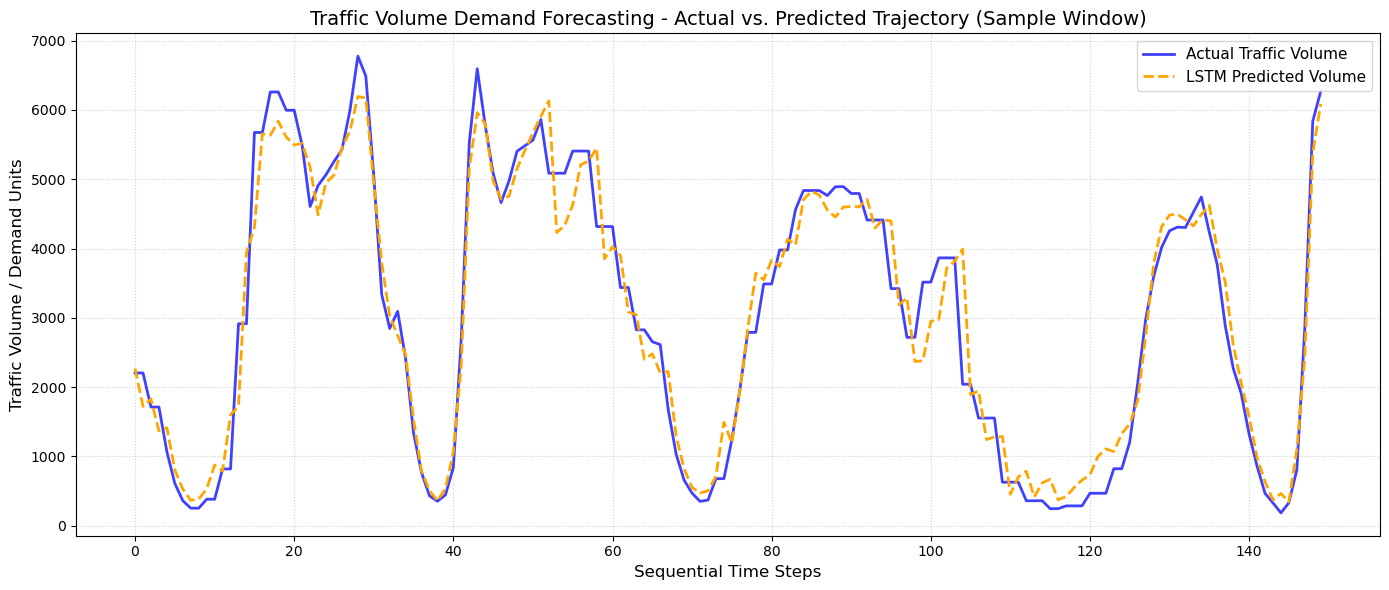

2026-09-27 16:30:08 - INFO - Forecasting routine execution run completed successfully.


In [14]:
logger.info("Running deep network evaluation metrics over the test validation split...")
predictions = lstm_network.predict(X_test, verbose=0)

# Rescale performance outputs back into original numerical domain parameters
predictions_actual = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Compute high-fidelity telemetry performance metrics
mae = mean_absolute_error(y_test_actual, predictions_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
mape = np.mean(np.abs((y_test_actual - predictions_actual) / y_test_actual)) * 100

logger.info("==== NETWORK PERFORMANCE RESULTS ====")
logger.info(f"Mean Absolute Error (MAE)      : {mae:.2f}")
logger.info(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
logger.info(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# ==========================================
# 7. MATPLOTLIB VISUALIZATION SCHEMATICS
# ==========================================
logger.info("Generating trajectory comparison charts...")
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual[:150], label='Actual Traffic Volume', color='blue', alpha=0.75, linewidth=2)
plt.plot(predictions_actual[:150], label='LSTM Predicted Volume', color='orange', linestyle='--', linewidth=2)
plt.title('Traffic Volume Demand Forecasting - Actual vs. Predicted Trajectory (Sample Window)', fontsize=14)
plt.xlabel('Sequential Time Steps', fontsize=12)
plt.ylabel('Traffic Volume / Demand Units', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
logger.info("Forecasting routine execution run completed successfully.")